# Model Evaluation and Comparison

Comparing the performance of Logistic Regression, Random Forest, and XGBoost models.

In [4]:
# Imports
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('../data/final_cleaned_data.csv')
X = df.drop(['ID', 'Reached.on.Time_Y.N'], axis=1)
y = df['Reached.on.Time_Y.N']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('Data loaded and split')

Data loaded and split


In [5]:
# Load models
lr_model = joblib.load('../models/logistic_regression.pkl')
rf_model = joblib.load('../models/random_forest.pkl')
xgb_model = joblib.load('../models/xgboost.pkl')

models = {
    'Logistic Regression': lr_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model
}

print('Models loaded')

Models loaded


In [6]:
# Evaluate each model
results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
    
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUC': auc
    })

results_df = pd.DataFrame(results)
print('Model Comparison:')
print(results_df)

Model Comparison:
                 Model  Accuracy  Precision    Recall  F1-Score       AUC
0  Logistic Regression  0.644091   0.706708  0.690023  0.698266  0.728564
1        Random Forest  0.671364   0.887139  0.514851  0.651566  0.740306
2              XGBoost  0.663636   0.802534  0.578827  0.672566  0.739208


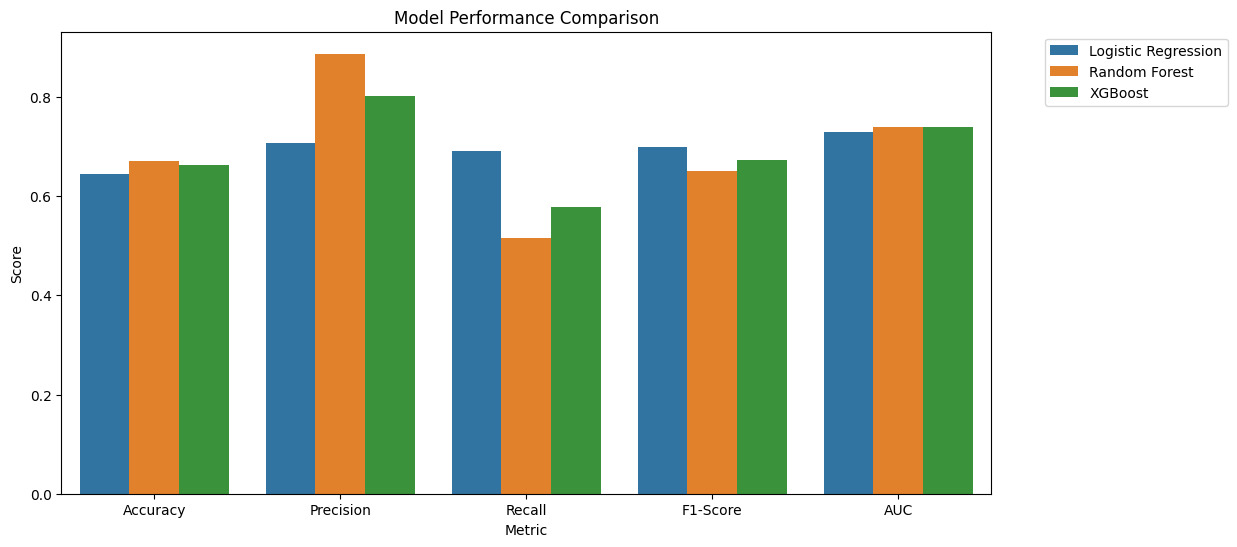

In [7]:
# Visualize comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
results_melted = results_df.melt(id_vars='Model', value_vars=metrics, var_name='Metric', value_name='Score')

plt.figure(figsize=(12,6))
sns.barplot(x='Metric', y='Score', hue='Model', data=results_melted)
plt.title('Model Performance Comparison')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [8]:
# Select best model
best_model_name = results_df.loc[results_df['Accuracy'].idxmax(), 'Model']
print(f'Best model based on accuracy: {best_model_name}')

# Save best model
best_model = models[best_model_name]
joblib.dump(best_model, '../models/best_model.pkl')
print('Best model saved as best_model.pkl')

Best model based on accuracy: Random Forest
Best model saved as best_model.pkl


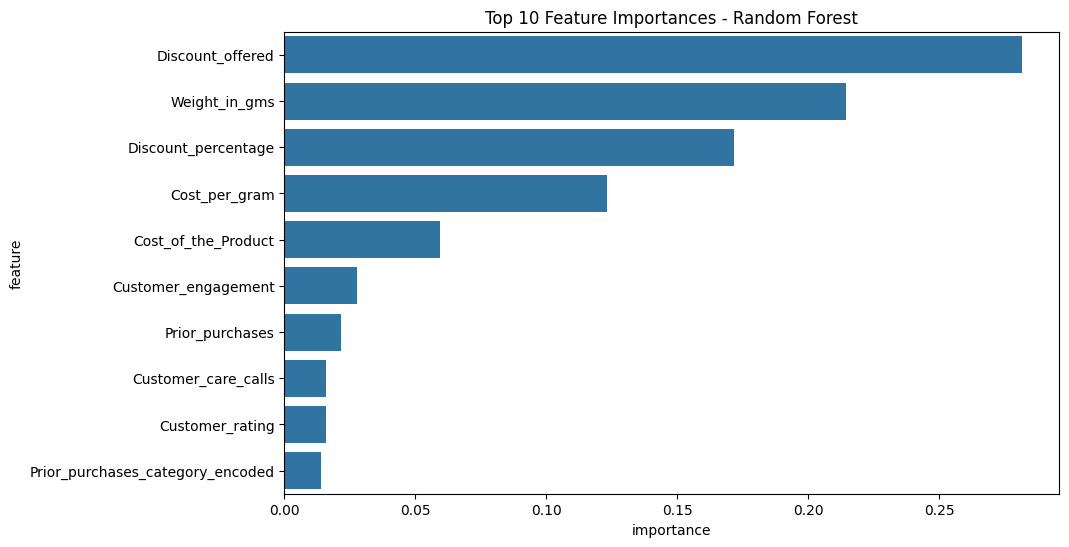

In [9]:
# Feature importance for best model
if hasattr(best_model, 'feature_importances_'):
    importance = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    importance = best_model.coef_[0]
else:
    importance = None

if importance is not None:
    feat_imp = pd.DataFrame({'feature': X.columns, 'importance': importance})
    feat_imp = feat_imp.sort_values('importance', key=abs, ascending=False).head(10)
    
    plt.figure(figsize=(10,6))
    sns.barplot(x='importance', y='feature', data=feat_imp)
    plt.title(f'Top 10 Feature Importances - {best_model_name}')
    plt.show()